## Import Liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Conv2D, Add
# from keras import Sequential
# from keras.layers import Input, Flatten, Conv2D, Dense, MaxPool2D
from keras.models import Model

In [2]:
import os
import tifffile as tiff
from glob import glob

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Model Architecture

In [4]:
def build_srcnn(input_shape=(None, None, 3)):
    """
    Builds a 3-layer SRCNN model.

    Parameters:
        input_shape (tuple): Shape of input image (H, W, C)

    Returns:
        model (tf.keras.Model): SRCNN model
    """

    inputs = Input(shape=input_shape)

    # Layer 1: Patch extraction
    x = Conv2D(
        filters=64,
        kernel_size=(9, 9),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv1'
    )(inputs)

    # Layer 2: Non-linear mapping
    x = Conv2D(
        filters=32,
        kernel_size=(5, 5),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv2'
    )(x)

    # Layer 3: Reconstruction
    outputs = Conv2D(
        filters=3,
        kernel_size=(5, 5),
        strides=(1, 1),
        padding='same',
        activation='linear',
        name='conv3'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='SRCNN')

    return model

In [24]:
# model2=Sequential([
#     Input(shape=(None, None, 3)),
#     Conv2D(64, (9, 9), padding='same', activation='relu'), # default value of stride=(1,1)
#     Conv2D(32, (5, 5), padding='same', activation='relu'),
#     Conv2D(3, (5, 5), padding='same', activation='linear')
# ])
# model2.summary()

In [5]:
# Create the model
model = build_srcnn(input_shape=(None, None,3))

# Display model summary
model.summary()

I0000 00:00:1786433894.549852      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786433894.552650      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, None, None, 64) │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, None, None, 32) │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, None, None, 3)  │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,251 (270.51 KB)

 Trainable params: 69,251 (270.51 KB)

 Non-trainable params: 0 (0.00 B)

## Creating data pipeline

In [4]:
TRAIN_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/HR_0.5m"
TRAIN_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/LR_1m"

VAL_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/HR_0.5m"
VAL_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/LR_1m"

TEST_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/test/HR_0.5m"
TEST_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/test/LR_1m"

- now every 6th patch is irrespective to any resolution is smaller in size
  > format (H, W, C) I don't know why this happen
    - for HR ideal: (512, 512, 3), (n+6)th patch: (512, 440, 3)
    - for LR_1m ideal: (256, 256, 3), (n+6)th patch: (256, 220, 3)
    - for LR_2m ideal: (128, 128, 3), (n+6)th patch: (128, 110, 3)

- I have 2 solutions:
    - Filter the bad/edge patches, in get_image_pairs()`
        - SRCNN is fully convolutional model, so it can process images of any size at inference
    - Add padding to the edge patches, inside `preprocess()`
```
lr = tf.image.resize_with_crop_or_pad(lr, 256, 256)
hr = tf.image.resize_with_crop_or_pad(hr, 512, 512)
```
- for now I choose to filter the edge patches

In [5]:
def get_image_pairs(hr_root, lr_root):

    hr_paths = sorted(glob(os.path.join(hr_root, "*", "*.tif")))
    lr_paths = sorted(glob(os.path.join(lr_root, "*", "*.tif")))
    # assert len(hr_paths) == len(lr_paths), "HR and LR image count mismatch!"
    # return hr_paths, lr_paths
    
    good_hr = []
    good_lr = []

    for hr, lr in zip(hr_paths, lr_paths):

        hr_img = tiff.imread(hr)
        lr_img = tiff.imread(lr)

        if hr_img.shape == (512,512,3) and lr_img.shape == (256,256,3):
            good_hr.append(hr)
            good_lr.append(lr)

    return good_hr, good_lr

In [6]:
train_hr, train_lr = get_image_pairs(TRAIN_HR, TRAIN_LR)
val_hr, val_lr = get_image_pairs(VAL_HR, VAL_LR)

print("Training patches :", len(train_hr))
print("Validation patches :", len(val_hr))

Training patches : 4375
Validation patches : 925


In [7]:
# import tifffile as tiff
sample = tiff.imread(train_hr[0])

print(sample.dtype)
print(sample.min(), sample.max())

uint8
0 240


In [10]:
def load_image(lr_path, hr_path):

    lr = tiff.imread(lr_path.decode())

    hr = tiff.imread(hr_path.decode())

    return lr.astype(np.float32), hr.astype(np.float32)

In [9]:
def preprocess(lr_path, hr_path):
# uses tf.numpy_function to wrap a regular Python/NumPy function (load_image) 
# so it can be used inside a TensorFlow data pipeline
    lr, hr = tf.numpy_function(
        load_image,
        [lr_path, hr_path],
        [tf.float32, tf.float32]
    )

    lr.set_shape([256,256,3])
    hr.set_shape([512,512,3])

    # Bicubic Upsampling
    lr = tf.image.resize(
        lr,
        [512,512],
        method='bicubic'
    )

    # Normalize

    # lr = lr / 255.0 # I can't use this because bicubic overshoot the value (like 260) at sharp edges
    # hr = hr / 255.0
    
    # Normalize and limit to [0, 1]
    lr = tf.clip_by_value(lr / 255.0, 0.0, 1.0)
    hr = tf.clip_by_value(hr / 255.0, 0.0, 1.0)

    return lr, hr

In [11]:
CROP_SIZE = 128

def preprocess_v2(lr_path, hr_path):
    # do random crop do make even smaller patches
    lr, hr = tf.numpy_function(
        load_image,
        [lr_path, hr_path],
        [tf.float32, tf.float32]
    )
    
    lr.set_shape([256,256,3])
    hr.set_shape([512,512,3])

    lr_upscaled = tf.image.resize(lr, [512,512], method='bicubic')
    
    lr_upscaled = tf.clip_by_value(lr_upscaled / 255.0, 0.0, 1.0)
    hr = tf.clip_by_value(hr / 255.0, 0.0, 1.0)

    # Stack LR and HR on the channel axis so the SAME crop
    # coordinates are applied to both (keeps them aligned)
    combined = tf.concat([lr_upscaled, hr], axis=-1)  # (512, 512, 6)
    combined_crop = tf.image.random_crop(combined, size=[CROP_SIZE, CROP_SIZE, 6])

    lr_crop = combined_crop[..., :3]
    hr_crop = combined_crop[..., 3:]
    return lr_crop, hr_crop

## Defining TensorFlow dataset
- dataset: (lr_image, hr_image)

In [12]:
# BATCH_SIZE = 16
BATCH_SIZE = 8
# BATCH_SIZE = 4
# BATCH_SIZE = 2

AUTOTUNE = tf.data.AUTOTUNE


train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_lr, train_hr)
)

train_dataset = (
    train_dataset
    .shuffle(1000)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_lr, val_hr)
)

val_dataset = (
    val_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [13]:
BATCH_SIZE_v2=32

train_dataset_v2 = tf.data.Dataset.from_tensor_slices(
    (train_lr, train_hr)
)

train_dataset_v2 = (
    train_dataset_v2
    .shuffle(1000)
    .map(preprocess_v2, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE_v2)
    .prefetch(AUTOTUNE)
)

In [17]:
checkpoint_basic = tf.keras.callbacks.ModelCheckpoint(
    "best_srcnn_basic.keras",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_residual = tf.keras.callbacks.ModelCheckpoint(
    "best_srcnn_residual.keras",
    monitor="val_loss",
    save_best_only=True
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    # patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
    # patience=3
)

In [42]:
# for lr_path in train_lr[:20]:
#     img = tiff.imread(lr_path)
#     print(img.shape)

## Model training

In [15]:
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(
#         learning_rate=1e-4
#     ),
#     loss='mse',
#     metrics=['mae']
# )

# Uses both the GPUs
strategy = tf.distribute.MirroredStrategy()

print("Number of devices:", strategy.num_replicas_in_sync)

with strategy.scope():
    model = build_srcnn()      # model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=['mae'],
        # tf.keras.metrics.MeanSquaredError(name='mse'),
        tf.keras.metrics.PSNR(max_val=1.0, name='psnr')
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


- Here's all the internal working
    - TensorFlow detects both GPUs
    - A **copy of the model** is created on each GPU. Initially, both copies have identical weights.
    - The **batch is split** automatically
        - If batch=32, it splits into 16, 16. Each GPU performs the forward and backward pass on its own portion of the batch.
    - After computing gradients: TensorFlow uses an efficient communication method (such as NCCL on NVIDIA GPUs) to **average the gradients**, applies a single optimizer update, and then keeps the model weights synchronized across both GPUs.

In [17]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint_basic,
               earlystop,
               reduce_lr]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [18]:
model.save("SRCNN_Final.keras")
model.save_weights('srcnn_model.weights.h5')
pd.DataFrame(history.history).to_csv("srcnn_history.csv", index=False)

## Testing model1

In [14]:
test_hr, test_lr = get_image_pairs(TEST_HR, TEST_LR)

In [15]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_lr, test_hr)
)

test_dataset = (
    test_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [21]:
lr, hr = next(iter(test_dataset))

# Bicubic baseline
bicubic = tf.image.resize(lr, [512, 512], method="bicubic")

# SRCNN prediction
sr = model.predict(bicubic, verbose=0)

# PSNR
bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
srcnn_psnr = tf.image.psnr(hr, sr, max_val=1.0)

print("Bicubic PSNR:", bicubic_psnr.numpy().mean())
print("SRCNN PSNR :", srcnn_psnr.numpy().mean())

Bicubic PSNR: 24.800682
SRCNN PSNR : 26.05004


In [41]:
def plot_image(org_img, bicubic_img, sr_img):
    # Convert TensorFlow tensor to NumPy
    if tf.is_tensor(org_img):
        org_img = org_img.numpy()

    if tf.is_tensor(bicubic_img):
        bicubic_img = bicubic_img.numpy()

    # Remove batch dimension if present
    org_img = np.squeeze(org_img)
    bicubic_img = np.squeeze(bicubic_img)
    sr_img = np.squeeze(sr_img)

    # Convert CHW -> HWC if necessary
    if org_img.ndim == 3 and org_img.shape[0] in [1, 3]:
        org_img = org_img.transpose(1, 2, 0)

    if bicubic_img.ndim == 3 and bicubic_img.shape[0] in [1, 3]:
        bicubic_img = bicubic_img.transpose(1, 2, 0)

    if sr_img.ndim == 3 and sr_img.shape[0] in [1, 3]:
        sr_img = sr_img.transpose(1, 2, 0)

    # Keep values in the normalized [0, 1] range
    org_img = np.clip(org_img, 0, 1)
    bicubic_img = np.clip(bicubic_img, 0, 1)
    sr_img = np.clip(sr_img, 0, 1)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(org_img)
    plt.title("Original HR Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(bicubic_img)
    plt.title("Bicubic Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sr_img)
    plt.title("SRCNN Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

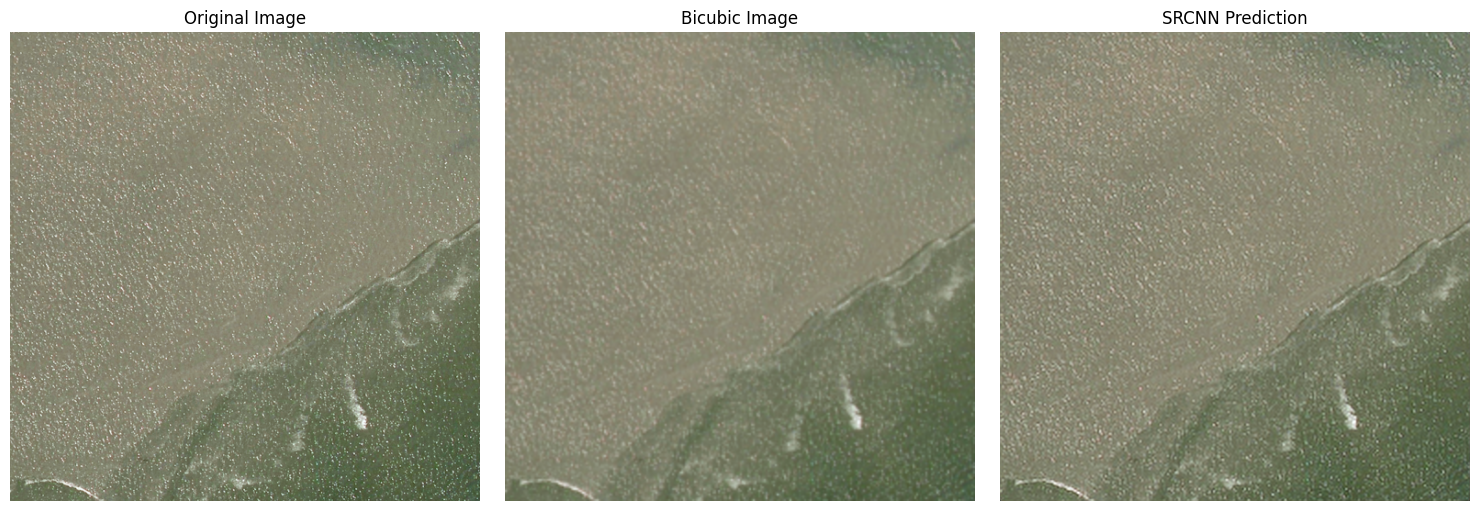

In [61]:
plot_image(hr[7],
           bicubic[7],
           sr[7])

In [62]:
hr.shape

TensorShape([8, 512, 512, 3])

## Making deeper SRCNN model (using Resudial learning)

- the output of the Conv layers is not necessarily the final/generated HR image.
- It is the residual:
    - R(x)=information that needs to be added
- Then: `Output=Input+Residual`
- so if the input has: basic structure + some details
- the networks learns: missing details
- then output becomes: basic structure + some details + missing details

In [19]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv2D, Add
# from tensorflow.keras.models import Model

# 5 layered model
def build_residual_srcnn(input_shape=(None, None, 3)):
    """
    Builds a residual SRCNN model for super-resolution.
    """

    inputs = Input(shape=input_shape)

    # Residual learning branch
    x = Conv2D(
        filters=128,
        kernel_size=(9, 9),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv1'
    )(inputs)

    x = Conv2D(
        filters=64,
        kernel_size=(9, 9),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv2'
    )(x)

    x = Conv2D(
        filters=32,
        kernel_size=(9, 9),
        strides=(1, 1),
        padding='same',
        activation='relu',
        name='conv3'
    )(x)

    # Learn the residual: 3-channel output
    residual = Conv2D(
        filters=3,
        kernel_size=(9, 9),
        padding='same',
        activation='linear',
        # for layer isn't randomly initialized weights, it init near zero
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=1e-2),
        # kernel_initializer='zeros',
        bias_initializer='zeros',
        name='residual'
    )(x)

    # Skip connection
    outputs = Add(name='residual_add')([inputs, residual])

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name='Residual_SRCNN'
    )

    return model

In [18]:
# Create the model
model2 = build_residual_srcnn(input_shape=(None, None,3))

# Display model summary
model2.summary()

Model: "Residual_SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, None,      │     31,232 │ input_layer_1[0]… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, None,      │    663,616 │ conv1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, None,      │    165,920 │ conv2[0][0]       │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Conv2D)   │ (None, None,      │      7,779 │ conv3[0][0]       │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, None,      │          0 │ input_layer_1[0]… │
│                     │ None, 3)          │            │ residual[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 868,547 (3.31 MB)

 Trainable params: 868,547 (3.31 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Uses both the GPUs
strategy = tf.distribute.MirroredStrategy()

print("Number of devices:", strategy.num_replicas_in_sync)

with strategy.scope():
    model2 = build_residual_srcnn()      # model
    model2.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=[
            'mae',
             # tf.keras.metrics.MeanSquaredError(name='mse'),
        ]
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


## Training Model2

In [ ]:
history2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint_residual,
               earlystop,
               reduce_lr]
)

Epoch 1/100
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
547/547 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - loss: 0.0012 - mae: 0.0215 - val_loss: 0.0010 - val_mae: 0.0199 - learning_rate: 1.0000e-04
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 904s 2s/step - loss: 9.9113e-04 - mae: 0.0195 - val_loss: 9.8338e-04 - val_mae: 0.0193 - learning_rate: 1.0000e-04
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 909s 2s/step - loss: 9.4920e-04 - mae: 0.0191 - val_loss: 9.5211e-04 - val_mae: 0.0190 - learning_rate: 1.0000e-04
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 911s 2s/step - loss: 9.2227e-04 - mae: 0.0188 - val_loss: 9.2820e-04 - val_mae: 0.0187 - learning_rate: 1.0000e-04
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - loss: 9.0125e-04 - mae: 0.0185 - val_loss: 9.1208e-04 - val_mae: 0.0185 - learning_rate: 1.0000e-04
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 913s 2s/step - loss: 8.8620

In [ ]:
model.save("residual_srcnn.keras")
model.save_weights('residual_srcnn_model.weights.h5')
pd.DataFrame(history2.history).to_csv("residual_srcnn_history.csv", index=False)

In [40]:
lr, hr = next(iter(test_dataset))

# Bicubic baseline
bicubic = tf.image.resize(lr, [512, 512], method="bicubic")

# SRCNN prediction
sr = model2.predict(bicubic, verbose=0)

# PSNR
bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
srcnn_psnr = tf.image.psnr(hr, sr, max_val=1.0)

print("Bicubic PSNR:", bicubic_psnr.numpy().mean())
print("SRCNN PSNR :", srcnn_psnr.numpy().mean())

Bicubic PSNR: 31.292923
SRCNN PSNR : 31.2929


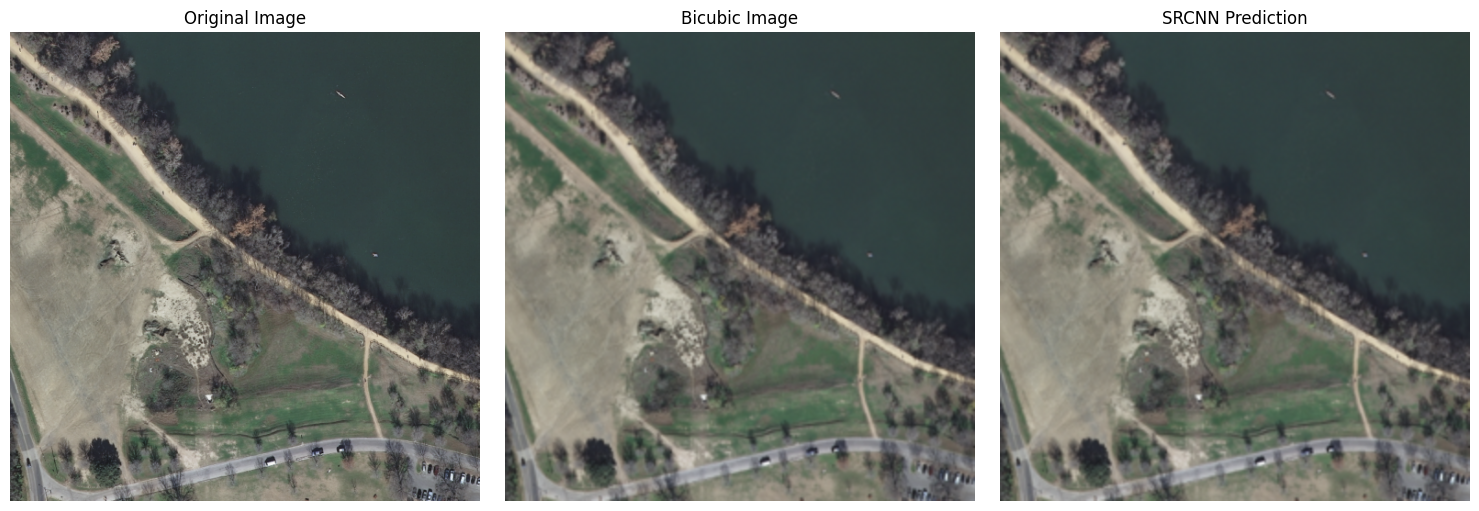

In [41]:
plot_image(hr[1],
           bicubic[1],
           sr[1])

In [63]:
lr_batch, hr_batch = next(iter(train_dataset))

print("LR:")
print("min:", tf.reduce_min(lr_batch).numpy())
print("max:", tf.reduce_max(lr_batch).numpy())
print("mean:", tf.reduce_mean(lr_batch).numpy())

print("\nHR:")
print("min:", tf.reduce_min(hr_batch).numpy())
print("max:", tf.reduce_max(hr_batch).numpy())
print("mean:", tf.reduce_mean(hr_batch).numpy())

LR:
min: 0.06109284
max: 0.9539757
mean: 0.40745798

HR:
min: 0.047058824
max: 0.99607843
mean: 0.40745857


## Diagnosing Why a Residual Model Is not learning
1. Overfit model on 1 Batch
- I'm getting same mse and psnr value (up to 3 decimal places) of both test model and bicubic model
    - on learning_rate=1e-4 an without kernel_initializer='zeros'
- And with kernel_initializer='zeros'still I got same mse and psnr values for both the models

In [69]:
with strategy.scope():
    test_model = build_residual_srcnn()      # model
    test_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=[
            'mae',
             # tf.keras.metrics.MeanSquaredError(name='mse'),
        ]
    )

In [70]:
lr_batch, hr_batch = next(iter(train_dataset))
test_history = test_model.fit(
    lr_batch, hr_batch,
    # validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint_residual,
               earlystop,
               reduce_lr]
)

Epoch 1/100
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0016 - mae: 0.0254 - learning_rate: 1.0000e-04
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0254 - learning_rate: 1.0000e-04
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0255 - learning_rate: 1.0000e-04
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0253 - learning_rate: 1.0000e-04
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0254 - learning_rate: 1.0000e-04
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0253 - learning_rate: 1.0000e-04
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0253 - learning_rate: 1.0000e-04
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0016 - mae: 0.0252 - learning_rate: 1.0000e-04


In [71]:
# Bicubic baseline
bicubic_mse = tf.reduce_mean(
    tf.square(hr_batch - lr_batch)
)

# Model prediction
pred = model2(lr_batch, training=False)

model_mse = tf.reduce_mean(
    tf.square(hr_batch - pred)
)

print("Bicubic MSE:", bicubic_mse.numpy())
print("Model MSE:  ", model_mse.numpy())

Bicubic MSE: 0.0015930746
Model MSE:   0.0015930763


In [72]:
bicubic_psnr = tf.image.psnr(
    hr_batch,
    tf.clip_by_value(lr_batch, 0.0, 1.0),
    max_val=1.0
)

model_psnr = tf.image.psnr(
    hr_batch,
    tf.clip_by_value(pred, 0.0, 1.0),
    max_val=1.0
)

print("Bicubic PSNR:", tf.reduce_mean(bicubic_psnr).numpy())
print("Model PSNR:  ", tf.reduce_mean(model_psnr).numpy())

Bicubic PSNR: 28.473963
Model PSNR:   28.473957


In [48]:
print("LR:", tf.reduce_min(lr_batch).numpy(),
           tf.reduce_max(lr_batch).numpy(),
           lr_batch.shape)

print("HR:", tf.reduce_min(hr_batch).numpy(),
           tf.reduce_max(hr_batch).numpy(),
           hr_batch.shape)

LR: 0.031120988 1.02449 (8, 512, 512, 3)
HR: 0.0 1.0 (8, 512, 512, 3)


- Now the suspects is that residual branch isn't learning

In [75]:
residual_target = hr_batch - lr_batch

print("Residual:")
print("min :", tf.reduce_min(residual_target).numpy())
print("max :", tf.reduce_max(residual_target).numpy())
print("mean:", tf.reduce_mean(residual_target).numpy())
print("std :", tf.math.reduce_std(residual_target).numpy())

print("Residual MSE:",
      tf.reduce_mean(tf.square(residual_target)).numpy())
print("Residual MAE:",
      tf.reduce_mean(tf.abs(residual_target)).numpy())

Residual:
min : -0.4355749
max : 0.44758853
mean: -2.9149267e-05
std : 0.039913327
Residual MSE: 0.0015930746
Residual MAE: 0.025440993


In [76]:
with tf.GradientTape() as tape:
    pred = model2(lr_batch, training=True)
    loss = tf.reduce_mean(tf.square(hr_batch - pred))

grads = tape.gradient(loss, model2.trainable_variables)

for var, grad in zip(model2.trainable_variables, grads):
    print(
        var.name,
        "gradient mean:",
        tf.reduce_mean(tf.abs(grad)).numpy(),
        "gradient max:",
        tf.reduce_max(tf.abs(grad)).numpy()
    )

kernel gradient mean: 8.398339e-11 gradient max: 2.3566085e-09
bias gradient mean: 2.3249404e-10 gradient max: 3.0103835e-09
kernel gradient mean: 5.976361e-12 gradient max: 1.0443517e-08
bias gradient mean: 2.816125e-10 gradient max: 7.994085e-09
kernel gradient mean: 4.1161345e-12 gradient max: 4.1376027e-09
bias gradient mean: 4.3924044e-07 gradient max: 5.116437e-06
kernel gradient mean: 3.7986503e-10 gradient max: 1.8721165e-08
bias gradient mean: 3.107343e-06 gradient max: 8.114278e-06


## Test 2
- Investigating `kernel_initializer='zeores'` and gradient problem
- Sucpecting **Dead Gradient/dying ReLU** problem
    - It is a problem in training neural networks where the gradient becomes zero (or extremely small), so the model’s weights stop updating effectively.
    - During Backpropogation, weight calculation
        - new weight = (old weight) - (learning rate) * (gradient)
    - If gradient=>0, the weight doesn't change
    - For ReLU, if a neuron's inputs consistently produce negative values, its gradient becomes zero

In [15]:
model_test_2=build_residual_srcnn()
model_test_2.summary()

Model: "Residual_SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, None,      │     31,232 │ input_layer_1[0]… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, None,      │    663,616 │ conv1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, None,      │    165,920 │ conv2[0][0]       │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Conv2D)   │ (None, None,      │      7,779 │ conv3[0][0]       │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, None,      │          0 │ input_layer_1[0]… │
│                     │ None, 3)          │            │ residual[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 868,547 (3.31 MB)

 Trainable params: 868,547 (3.31 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    model_test_2 = build_residual_srcnn()      # model
    model_test_2.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=[
            'mae',
             # tf.keras.metrics.MeanSquaredError(name='mse'),
        ]
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


- keeping `kernel_initializer='zeros`, observing the changes in conv1
    - results is zero
- now checking with `RandomNormal(mean=0.0, stddev=1e-3)`, it initialize weights near zero

In [36]:
lr_batch, hr_batch = next(iter(train_dataset))

w_before = model_test_2.get_layer('conv1').get_weights()[0].copy()
model_test_2.fit(lr_batch, hr_batch, epochs=1, verbose=1)
w_after = model_test_2.get_layer('conv1').get_weights()[0]

print(np.abs(w_after - w_before).max()) 

INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0014 - mae: 0.0253
9.963103e-05


### What happened
- Before (zero-init): `conv1's` weights changed by `0.0` after one epoch literally `no gradient` reached `conv1`. It was frozen, dead on arrival.
- After (random-init): conv1 changed by `7.9433434e-5` small, but `not zero`. Gradient is now flowing all the way back through the `network`. The residual branch can actually learn.

In [43]:
model_test_2.fit(lr_batch, hr_batch, epochs=10, verbose=1)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0208
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0208
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0209
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0209
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0208
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0208
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0207
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0207
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0207
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0011 - mae: 0.0207


### Checking PSNR

In [44]:
lr, hr = next(iter(test_dataset))

# Bicubic baseline
bicubic = tf.image.resize(lr, [512, 512], method="bicubic")

# SRCNN prediction
sr_test_2 = model_test_2.predict(bicubic, verbose=0)

# PSNR
bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
srcnn_psnr = tf.image.psnr(hr, sr_test_2, max_val=1.0)

print("Bicubic PSNR:", bicubic_psnr.numpy().mean())
print("SRCNN PSNR :", srcnn_psnr.numpy().mean())

Bicubic PSNR: 31.292923
SRCNN PSNR : 31.32581


## Model training on `training_dataset_v2`

In [20]:
strategy = tf.distribute.MirroredStrategy()

print("Number of devices:", strategy.num_replicas_in_sync)

with strategy.scope():
    model2_v2 = build_residual_srcnn()      # model
    model2_v2.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='mse',
        metrics=[
            'mae',
             # tf.keras.metrics.MeanSquaredError(name='mse'),
        ]
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [21]:
history2_v2 = model2_v2.fit(
    train_dataset_v2,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[checkpoint_residual,
               earlystop,
               reduce_lr]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

## Testing model_v2

In [26]:
bicubic_psnr_all=[]
srcnn_psnr_all=[]

for lr, hr in test_dataset:
    # Bicubic baseline
    bicubic = tf.image.resize(lr, [512, 512], method="bicubic")
    # SRCNN prediction
    sr = model2_v2.predict(bicubic, verbose=0)
    
    # PSNR
    bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
    srcnn_psnr = tf.image.psnr(hr, sr, max_val=1.0)
    
    # Store results
    bicubic_psnr_all.extend(bicubic_psnr.numpy())
    srcnn_psnr_all.extend(srcnn_psnr.numpy())

# Convert to numpy arrays
bicubic_psnr_all = np.array(bicubic_psnr_all)
srcnn_psnr_all = np.array(srcnn_psnr_all)

# Average PSNR over the ENTIRE test dataset
print("Bicubic PSNR:", bicubic_psnr_all.mean())
print("SRCNN PSNR :", srcnn_psnr_all.mean())

Bicubic PSNR: 29.175306
SRCNN PSNR : 31.844072


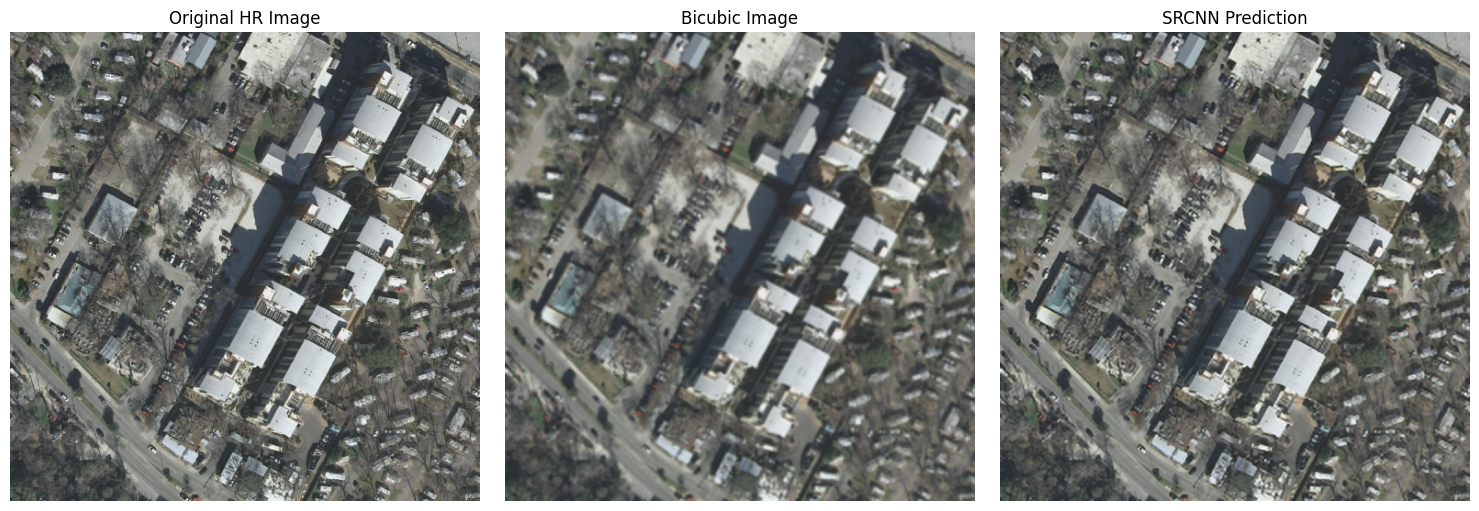

In [56]:
test_iter=iter(test_dataset)
for i in range(2):
    _=next(test_iter)
lr, hr=next(test_iter)
# lr, hr =next(iter(test_dataset))
bicubic_lr=tf.image.resize(lr[3], [512, 512], method="bicubic")
sr_test=model2_v2.predict(lr, verbose=0)
plot_image(hr[3],
           bicubic_lr,
           sr_test[3])

In [31]:
model2_v2.save("SRCNN_Final.keras")
model2_v2.save_weights('srcnn_model.weights.h5')
pd.DataFrame(history2_v2.history).to_csv("srcnn_history.csv", index=False)

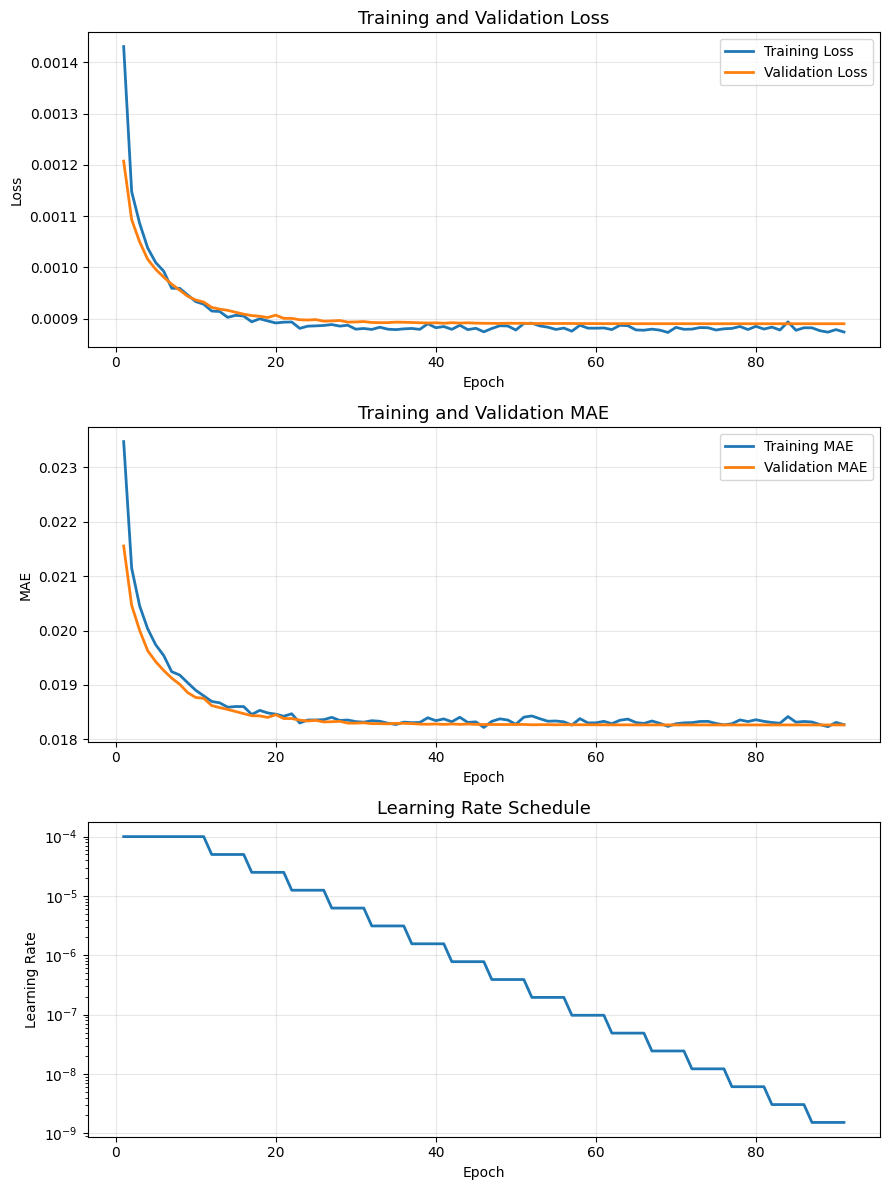

In [33]:
df = pd.DataFrame(history2_v2.history)

# If epoch column is not present
if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(9, 12))

# Training and Validation Loss
axes[0].plot(
    df["epoch"],
    df["loss"],
    label="Training Loss",
    linewidth=2
)

axes[0].plot(
    df["epoch"],
    df["val_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[0].set_title("Training and Validation Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training and Validation MAE
axes[1].plot(
    df["epoch"],
    df["mae"],
    label="Training MAE",
    linewidth=2
)

axes[1].plot(
    df["epoch"],
    df["val_mae"],
    label="Validation MAE",
    linewidth=2
)

axes[1].set_title("Training and Validation MAE", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(
    df["epoch"],
    df["learning_rate"],
    linewidth=2
)

axes[2].set_title("Learning Rate Schedule", fontsize=13)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)


# Overall layout
plt.tight_layout()

## Notes
- In residual learning for super-resolution:
    - The input image is passed through a main network that learns the missing details or residual.
    - At the same time, the input is passed through a **shortcut/skip** connection so its existing information is preserved.
    - The network learns something like: `Residual=Target HR image−Upsampled input`
    - Finally, the residual is added to the upsampled input to produce the high-resolution image: `HR=Upsampled(LR)+Residual`
- **In simple words**: instead of learning the whole high-resolution image from scratch, the network learns the missing information/details, while the skip connection preserves the information already present in the input.

```
LR image
   │
   ▼
Bicubic Upsampling
   │
   ▼
Upsampled LR ───────────────┐
   │                        │
   ▼                        │
Conv2D(128, 9×9)            │
   │                        │
Conv2D(64, 9×9)             │
   │                        │
Conv2D(32, 9×9)             │
   │                        │
Conv2D(3, 9×9)              │
   │                        │
   ▼                        │
 Learned Residual           │
   │                        │
   └─────────────► Add ◄────┘
                    │
                    ▼
                SR / HR output
```

## Important
- save the model weights
- save the history of model
- save the final model


### Note
- `models/srcnn.py` only store the architecture of the model; after the model is created, then I have to load the weights of my trained model into it, which was saved in `checkpoints/`
- `notebooks/` can contain (like experimentation stuffs):
    - SRCNN architecture
    - Dataset loading
    - Training loop
    - Validation
    - Loss calculation
    - Evaluation
    - Model saving
```
Dual-SR/
├── models/
│   ├── srcnn.py
│   └── dual_sr.py
│
├── checkpoints/
│   └── srcnn.pth
│   └── dual_sr.pth
│
├── notebooks/
│   └── srcnn_training.ipynb
│
├── datasets/
├── results/
└── README.md
```